# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | Employee Retention Prediction </p>

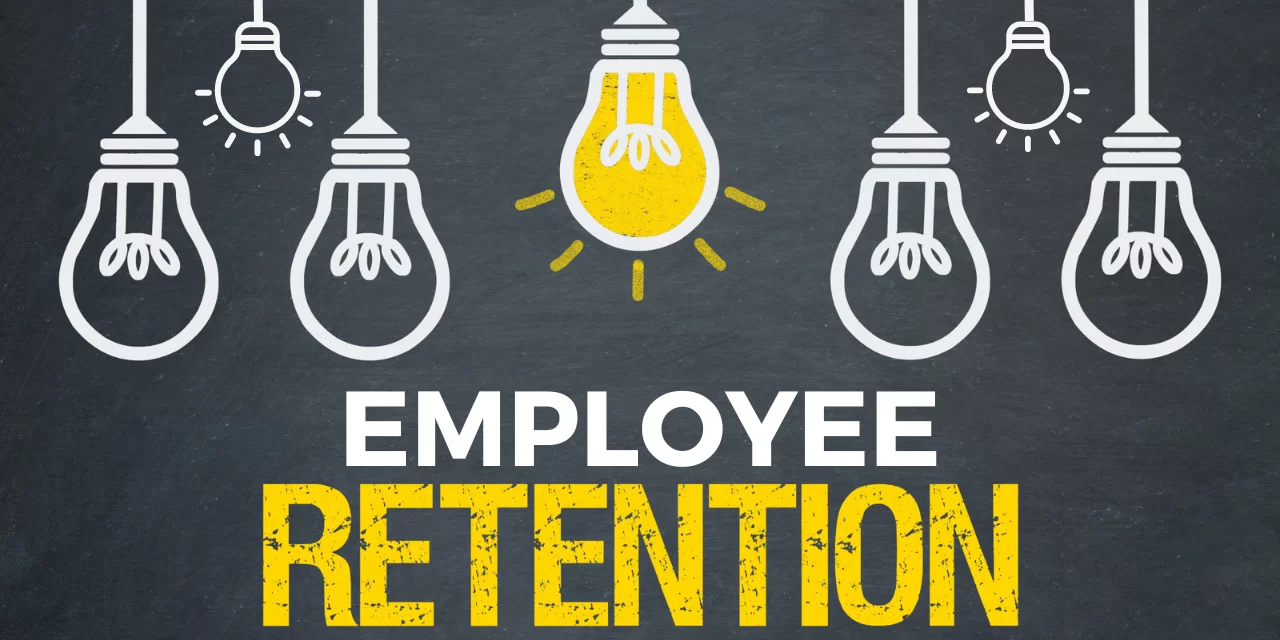

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Problem:</font></h3>

In this project we develop a machine learning model to predict whether __data scientists__ are likely to seek job changes, aiding in talent retention and recruitment planning. It should help in optimizing retention strategies, proactive recruitment, and better resource allocation using a predictive model, comprehensive data visualizations, and a comparative analysis of various machine learning algorithms.
 

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Objectives:</font></h3>

The primary objective of this project is to predict the likelihood of job change among data scientists using machine learning techniques, enabling organizations to make data-driven decisions for talent retention and workforce planning.

Specifically, this project aims to:

Analyze employee-related data to understand key factors influencing job change behavior through exploratory data analysis (EDA) and visualizations.

Preprocess and transform data by handling missing values, encoding categorical features, and scaling numerical variables to prepare it for machine learning models.

Develop and compare multiple machine learning models (such as Logistic Regression, Random Forest, and XGBoost) to identify the most effective algorithm for predicting employee job change.

Evaluate model performance using metrics such as accuracy, precision, recall, F1-score, and confusion matrix to ensure reliable predictions.

Generate job change probability scores for individual employees to support proactive retention strategies and recruitment planning.

Provide actionable insights through visualizations and predictive outputs that help organizations:

<h2 align="left"><font color=red>Let's get started:</font></h2>

<a id='libraries'></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>



In [1]:
# CORE LIBRARIES

import numpy as np
import pandas as pd

# Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Handling imbalanced data

from imblearn.over_sampling import SMOTE

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Ignore warnings for clean output

import warnings
warnings.filterwarnings('ignore')

<a id="read"></a>
# <p style="background-color:red ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:115%; text-align:left">

First of all, let's load the dataset:

In [2]:
train_df = pd.read_csv("aug_train.csv")
test_df = pd.read_csv("aug_test.csv")

In [3]:
train_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
####### DATASET SHAPE & STRUCTURE #########

In [5]:
print('Train Shape:',train_df.shape)
print('Test Shape :',test_df.shape)

Train Shape: (19158, 14)
Test Shape : (2129, 13)


In [6]:
###### Some datasets infoemation / understand the data 

train_df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:120%; text-align:left">

<h2 align="left"><font color=red>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|  
|__Enrollee_id__ | Unique ID for enrollee|

|__City__| City code|

|__Citydevelopmentindex__| Development index of the city (scaled)|

|__Gender__| Gender of enrolee|

|__Relevent_experience__| Relevent experience of enrolee|

|__Enrolled_university__| Type of University course enrolled if any|

|__Education_level__| Education level of enrolee|

|__Major_discipline__| Education major discipline of enrolee|

|__Experience__| Enrolee total experience in years|

|__Company_size__| No of employees in current employer's company|

|__Company_type__ | Type of current employer|

|__Lastnewjob__ | Difference in years between previous job and current job|

|__Training_hours__ | Training hours completed|

|__target__| 0 – Not looking for job change, 1 – Looking for a job change|

<a id='overview'></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [8]:
train_df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [9]:
train_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19153    False
19154    False
19155    False
19156    False
19157    False
Length: 19158, dtype: bool

In [10]:
train_df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


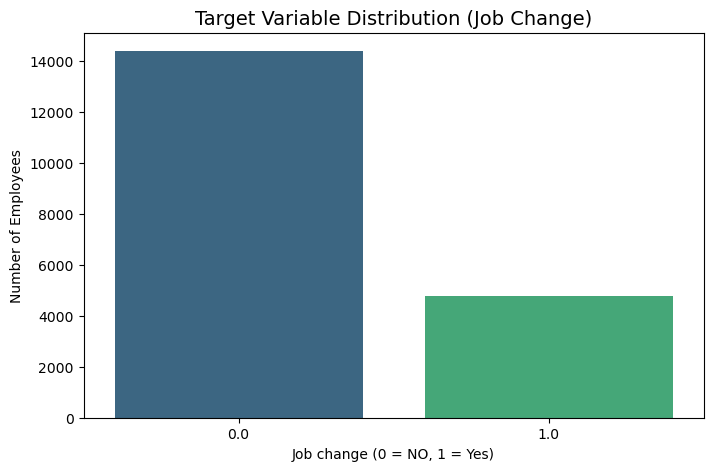

In [11]:
# Target Value Distribution 

plt.figure(figsize=(8,5))
sns.countplot(x='target', data=train_df, palette = 'viridis')
plt.title('Target Variable Distribution (Job Change)',fontsize=14)
plt.xlabel('Job change (0 = NO, 1 = Yes)')
plt.ylabel('Number of Employees')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The target variable distribution shows a clear class imbalance, with a majority of employees not changing jobs compared to those who do.
This indicates that job retention is more common, while job change represents a smaller but critical group.
Such imbalance can bias model performance if evaluated using accuracy alone.
Therefore, the model should prioritize recall for job changers to effectively identify employees at risk of attrition.    

    


In [12]:
###### ID COLUMN ( NO PREDICTIVE POWER)

id_column = 'enrollee_id'

In [13]:
train_df.drop(columns=[id_column],inplace=True)
test_df.drop(columns=[id_column],inplace=True)

In [16]:
############ MISSING VALUES ANALYSIS & DATAYPES UNDERSTANDING

In [17]:
train_df.isnull().sum()

city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [18]:
# 2.2 PERCENTAGE OF MISSING VALUES 

In [19]:
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_percent.sort_values(ascending=False)

company_type              32.049274
company_size              30.994885
gender                    23.530640
major_discipline          14.683161
education_level            2.401086
last_new_job               2.207955
enrolled_university        2.014824
experience                 0.339284
city                       0.000000
relevent_experience        0.000000
city_development_index     0.000000
training_hours             0.000000
target                     0.000000
dtype: float64

In [20]:
train_df.dtypes

city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

In [21]:
# 2.4 SEPRATE NUMERICAL AND CATEGORICAL COLUMNS 

In [22]:
numerical_cols = train_df.select_dtypes(include=['int64','float64']).columns
categorical_cols = train_df.select_dtypes(include=['object']).columns
print('Numerical Columns:',numerical_cols)
print('Categorical Columns:',categorical_cols)

Numerical Columns: Index(['city_development_index', 'training_hours', 'target'], dtype='object')
Categorical Columns: Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')


In [23]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


In [25]:
# APPLY MISSING VALUE IMPUTATION

########## NUMERICAL COLUMNS MEDIAN

for col in numerical_cols:
    train_df[col].fillna(train_df[col].median(),inplace=True)
  

##### CATEGORICAL COLUMNS - MODE

for col in categorical_cols:
    train_df[col].fillna(train_df[col].mode()[0],inplace=True)
    

In [26]:
train_df.isnull().sum()

city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [27]:
test_df.isnull().sum()

city                        0
city_development_index      0
gender                    508
relevent_experience         0
enrolled_university        31
education_level            52
major_discipline          312
experience                  5
company_size              622
company_type              634
last_new_job               40
training_hours              0
dtype: int64

In [28]:
# Loop through test columns only
for col in test_df.columns:

    # NUMERICAL COLUMNS → median from train
    if test_df[col].dtype in ['int64', 'float64']:
        test_df[col].fillna(train_df[col].median(), inplace=True)

    # CATEGORICAL / ORDINAL → mode from train
    else:
        test_df[col].fillna(train_df[col].mode()[0], inplace=True)


In [29]:
test_df.isnull().sum()


city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64

<a id='eda'></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:115%; text-align:left">

For our __Exploratory Data Analysis (EDA)__, we'll take it in two main steps:

>__1. Univariate Analysis__: Here, we'll focus on one feature at a time to understand its distribution and range.
>
>__2. Bivariate Analysis__: In this step, we'll explore the relationship between each feature and the target variable. This helps us figure out the importance and influence of each feature on the target outcome.

With these two steps, we aim to gain insights into the individual characteristics of the data and also how each feature relates to our main goal: __predicting the target variable__.

###### TARGET DISTRIBUTION REVISTED WITH PERCENTAGES ############

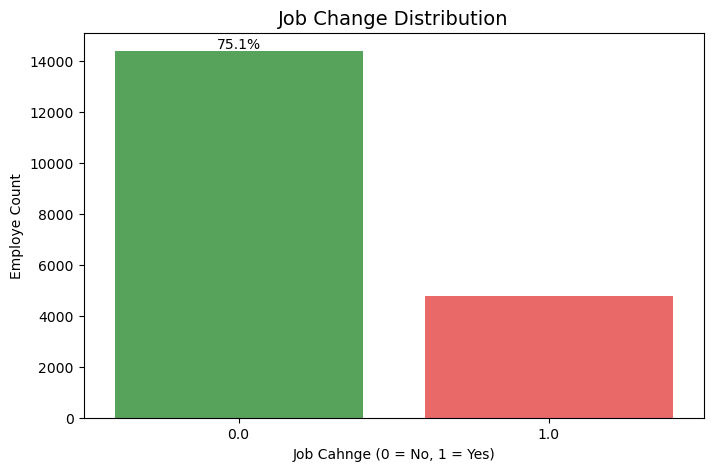

In [30]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='target',data=train_df,palette=['#4CAF50','#FF5252'])
plt.title('Job Change Distribution', fontsize=14)
plt.xlabel('Job Cahnge (0 = No, 1 = Yes)')
plt.ylabel('Employe Count')

####### ADD PERCENTAGE LABELS #######

for p in ax.patches:
    percentage=f"{100 * p.get_height() / len(train_df):.1f}%"
    ax.annotate(percentage, (p.get_x() + p.get_width()/2.,p.get_height()),
                ha='center',va='bottom')
    plt.show()
    


<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The job change distribution reveals a clear class imbalance, with approximately **75% of employees not changing jobs** and around **25% indicating job change**.  
This shows that employee retention is the dominant outcome in the dataset.  
The minority class (job changers) is crucial from a business perspective, as it represents potential attrition risk.  
Such imbalance can lead to biased model predictions if accuracy alone is considered.  
Therefore, evaluation metrics like **recall, F1-score, and ROC–AUC** are essential to effectively identify employees likely to leave.


In [31]:
######### EDUCATION LEVEL VS JOB CHANGE ###############

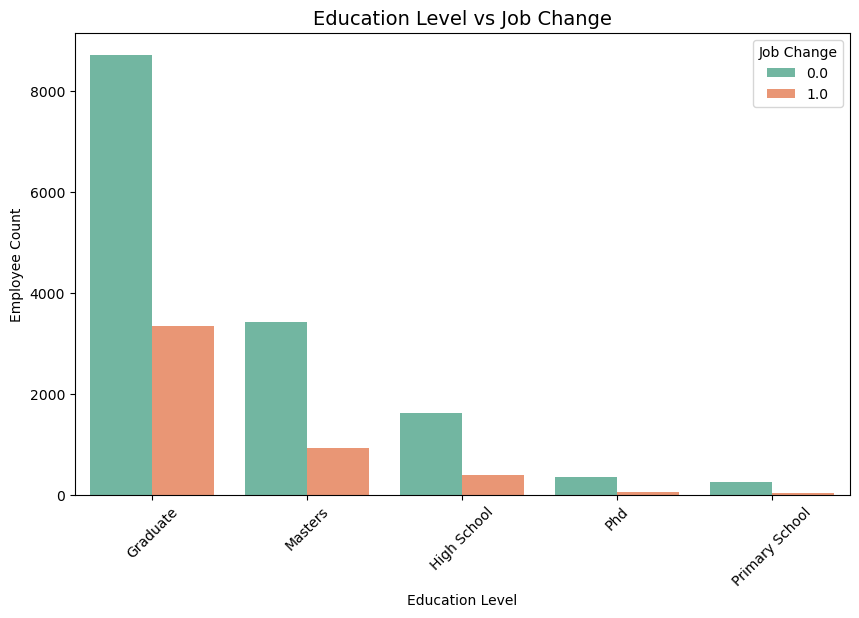

In [32]:
plt.figure(figsize=(10,6))
sns.countplot(x = 'education_level',hue='target',data=train_df,palette='Set2')
plt.xticks(rotation=45)
plt.title('Education Level vs Job Change',fontsize=14)
plt.xlabel('Education Level')
plt.ylabel('Employee Count')
plt.legend(title='Job Change')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The chart shows that employees with a **Graduate** and **Master’s** level education form the largest proportion of the workforce.  
Across all education levels, the number of employees who **do not change jobs** is higher than those who do.  
Job change is relatively more prominent among **Graduate and Master’s degree holders**, likely due to better external opportunities.  
Employees with **PhD and lower education levels** exhibit comparatively lower job change counts.  
This indicates that **education level is an influential factor** and should be considered in predicting employee attrition.


In [33]:
#### EXPERIENCE VS JOB CHANGE #########

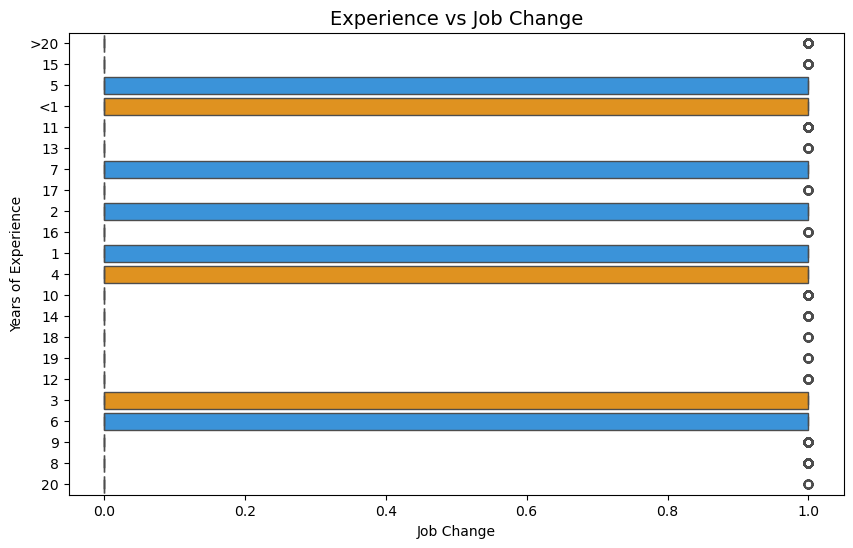

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='target',y='experience',data=train_df,palette=['#2196F3','#FF9800'])
plt.title('Experience vs Job Change',fontsize=14)
plt.xlabel('Job Change')
plt.ylabel('Years of Experience')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The visualization illustrates the relationship between **years of experience** and **job change behavior** among employees.  
Employees with **lower experience levels (less than 5 years)** show a higher tendency to change jobs.  
This may be attributed to early-career professionals seeking better growth opportunities and role alignment.  
As experience increases, the likelihood of job change generally declines, indicating improved job stability.  
Mid-level professionals exhibit a mixed pattern, balancing career growth with organizational loyalty.  
Highly experienced employees (15+ years) show comparatively lower job change frequency.  
This trend suggests that experience plays a **significant role in employee retention**.  
Therefore, years of experience is an important predictor in modeling job change behavior.


In [35]:
########## COMPANY SIZE IMAPACT ###########

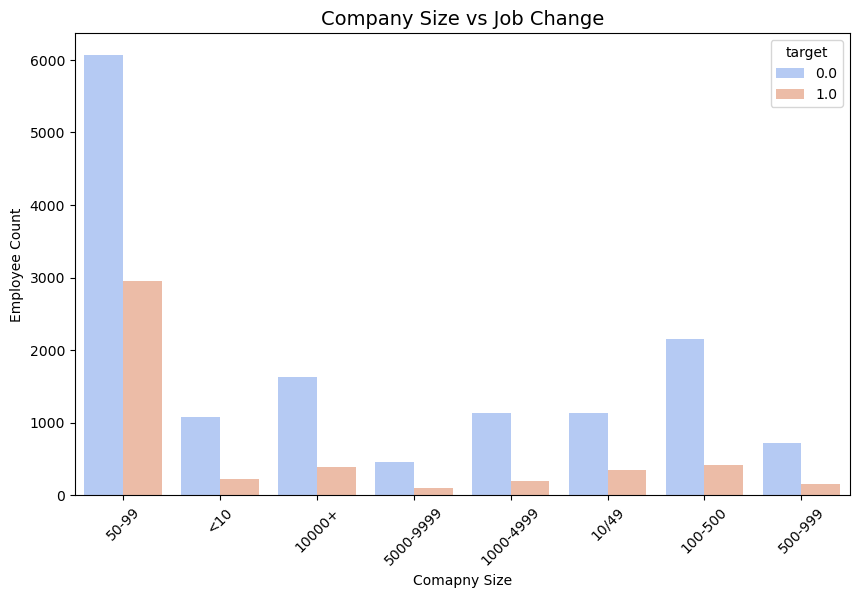

In [36]:
plt.figure(figsize=(10,6))
sns.countplot(x='company_size',hue='target',data=train_df,palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Company Size vs Job Change',fontsize=14)
plt.xlabel('Comapny Size')
plt.ylabel('Employee Count')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The chart highlights the relationship between **company size** and **employee job change behavior**.  
Employees working in **medium-sized companies (50–99 employees)** form the largest group across both job stayers and changers.  
Smaller organizations (less than 10 employees) show comparatively lower employee counts but a noticeable proportion of job changes.  
Larger companies tend to retain more employees, indicating better stability and structured career growth.  
Job change is observed across all company sizes, suggesting that attrition is not limited to a specific organization scale.  
Mid-sized firms display relatively higher job change counts compared to very large enterprises.  
This pattern may reflect limited growth opportunities or role saturation in mid-sized companies.  
Overall, **company size emerges as an important factor** influencing employee retention and job mobility.


In [37]:
########## Traning Hours Distribution ############

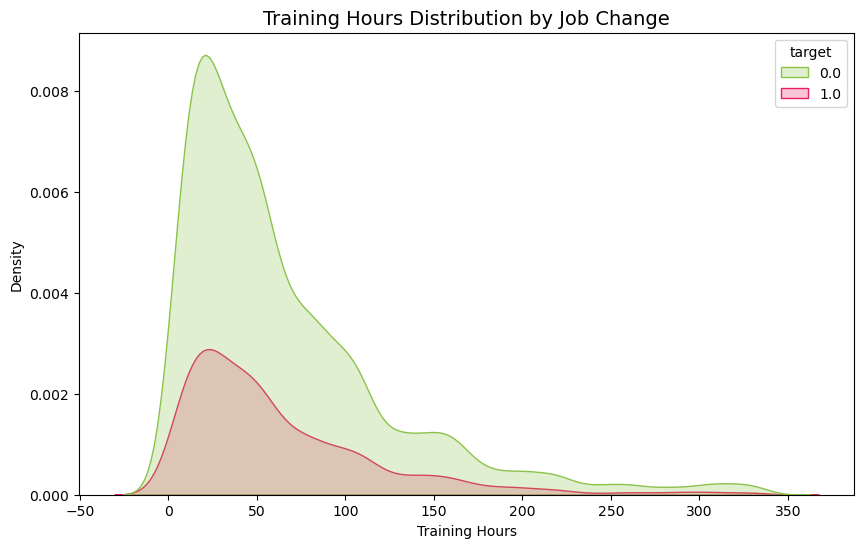

In [38]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=train_df, x='training_hours',hue='target',fill=True,palette=['#8BC34A', '#E91E63'])
plt.title('Training Hours Distribution by Job Change',fontsize=14)
plt.xlabel('Training Hours')
plt.ylabel('Density')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The distribution shows clear differences in **training hours** between employees who stayed and those who changed jobs.  
Employees who did not change jobs are more concentrated at **lower to moderate training hours**, indicating stable learning engagement.  
Job changers display a wider spread of training hours with a noticeable right skew.  
Higher training hours among job changers may reflect efforts to **upskill for better external opportunities**.  
Both groups show overlap, suggesting training alone does not fully determine job change decisions.  
Extreme training hours are relatively rare but appear more frequently among job changers.  
This pattern indicates that increased training does not always guarantee retention.  
Instead, training may sometimes enable employees to become more market-ready.  
Organizations should align training programs with **career progression and retention strategies**.  
Overall, training hours emerge as a **meaningful but non-exclusive factor** in predicting job change behavior.


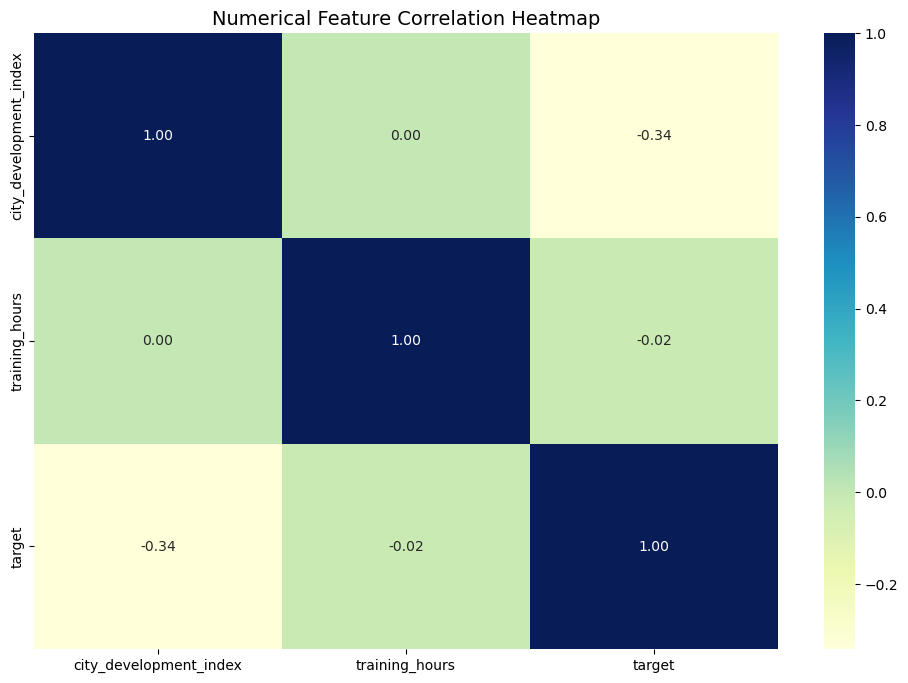

In [39]:
plt.figure(figsize=(12,8))
correlation = train_df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, cmap='YlGnBu',fmt='.2f')
plt.title('Numerical Feature Correlation Heatmap',fontsize=14)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The correlation heatmap illustrates the relationships among key numerical features and the target variable.  
The **city development index** shows a moderate negative correlation with job change, indicating that employees from more developed cities are less likely to change jobs.  
This suggests better opportunities, stability, or work environments in highly developed regions.  
**Training hours** exhibit a very weak negative correlation with the target, implying minimal direct linear impact on job change decisions.  
The near-zero correlation between city development index and training hours indicates feature independence.  
No strong multicollinearity is observed among the numerical variables.  
This is beneficial for machine learning models, especially linear algorithms.  
The findings indicate that job change behavior is influenced by multiple interacting factors rather than a single numerical feature.  
Therefore, non-linear models may better capture these complex relationships.


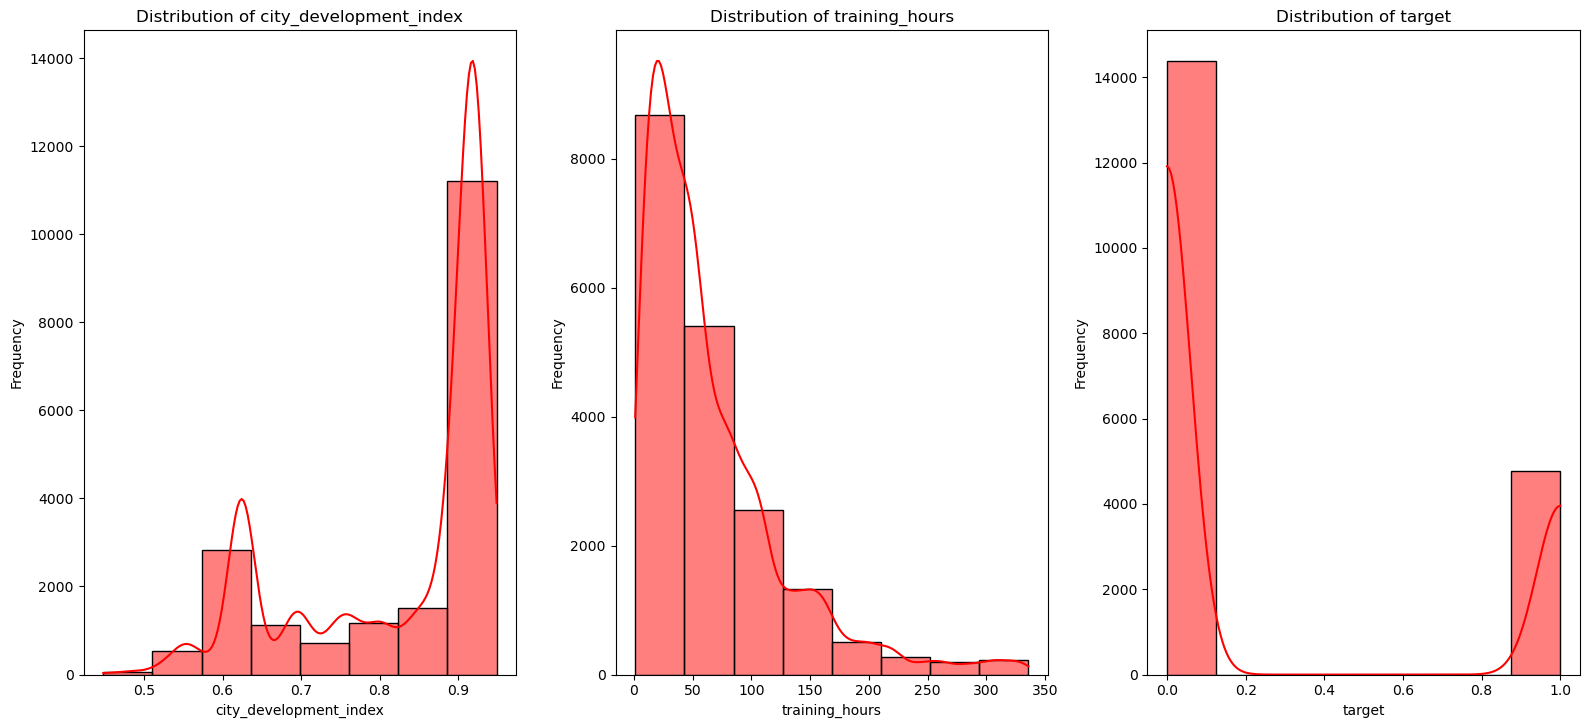

In [40]:

# Set figure size dynamically
num_cols = len(numerical_cols)
plt.figure(figsize=(16, 7 * num_cols))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_cols, 3, i)   # adjust columns if needed
    sns.histplot(
        train_df[col],
        bins=8,
        kde=True,
        color='red',
        edgecolor='black'
    )
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The distribution of **city_development_index** shows a higher concentration of values toward the upper range, indicating that most employees are from relatively well-developed cities.  
This suggests that urban and developed regions contribute a larger share of the workforce in the dataset.  
The **training_hours** distribution is right-skewed, with most employees receiving lower to moderate training hours and a few outliers with very high training exposure.  
Such skewness indicates variability in learning opportunities across employees.  
The **target variable distribution** confirms a clear class imbalance, with significantly more employees staying than changing jobs.  
This imbalance highlights the importance of careful model evaluation beyond accuracy.  
Overall, the numerical features are not normally distributed and exhibit skewness.  
These observations justify the need for **feature transformation and robust modeling techniques**.


<a id="preprocessing"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing</p>

In [41]:
########### HANDLING EXPERIENCE COLUMN ############

In [42]:
# FUNCTION TO CLEAN EXPERIENCE VALUES 

In [43]:
def clean_experience(x):
    if x=='<1':
        return 0
    elif x=='>20':
        return 21
    else:
        return int(x)

In [44]:
train_df['experience'] = train_df['experience'].apply(clean_experience)
test_df['experience'] = test_df['experience'].apply(clean_experience)

In [45]:
# Handling last_new_job Column

# This column shows how recently an employee changed jobs.

In [46]:
mapping = {
    'never': 0,
    '1':1,
    '2':2,
    '3':3,
    '4':4,
    '>4':5

}

In [47]:
train_df['last_new_job'] = train_df['last_new_job'].map(mapping)
test_df['last_new_job'] = test_df['last_new_job'].map(mapping)

In [48]:
train_df['last_new_job'].isna().sum()
test_df['last_new_job'].isna().sum()


np.int64(0)

In [49]:
train_df['last_new_job'].fillna(0, inplace=True)
test_df['last_new_job'].fillna(0, inplace=True)


In [50]:
train_df['last_new_job'].unique()


array([1, 5, 0, 4, 3, 2])

In [51]:
# 4.4 Feature: Training per Experience

In [52]:
train_df['training_per_exp'] = train_df['training_hours']/(train_df['experience']+1)
test_df['training_per_exp'] = test_df['training_hours']/(test_df['experience']+1)

In [53]:
###### ENCODING & SCALING

In [54]:
#1 . SEPRATE TARGET VARIABLE 

In [55]:
x = train_df.drop(columns=['target'])
y = train_df['target']

In [56]:
########## 2 ########### 

In [57]:
categorical_cols = x.select_dtypes(include='object').columns
numerical_cols = x.select_dtypes(include=['int64','float64']).columns

In [58]:
categorical_cols = [c for c in categorical_cols if c != 'target']


In [59]:
print("Categorical Columns:",categorical_cols)
print("Numerical Columns:",numerical_cols)

Categorical Columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']
Numerical Columns: Index(['city_development_index', 'experience', 'last_new_job',
       'training_hours', 'training_per_exp'],
      dtype='object')


In [60]:
##### feature scaling for numerical columns

In [61]:
scaler = StandardScaler()

In [62]:
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

In [63]:
if col in test_df.columns:
    test_df[col].unique()[:10]



In [64]:
if col in test_df.columns:
    test_df[col].apply(type).value_counts()



In [65]:
for col in categorical_cols:
    x[col] = x[col].astype(str)
    test_df[col] = test_df[col].astype(str)


In [66]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    'city',
    'gender',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'company_size',
    'company_type'
]

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x[categorical_cols] = oe.fit_transform(x[categorical_cols])
test_df[categorical_cols] = oe.transform(test_df[categorical_cols])

# 🔒 LOCK feature order after encoding
feature_names = x.columns.tolist()


In [67]:
scaler = StandardScaler()

In [68]:
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

In [69]:
########### hint #######

In [70]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [71]:
print("x_train shape:", x_train.shape)
print("x_val shape  :", x_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)

x_train shape: (15326, 13)
x_val shape  : (3832, 13)
y_train shape: (15326,)
y_val shape  : (3832,)


In [72]:
######### SMOTE #########

In [73]:
print("Before SMOTE")
print(y_train.value_counts())

Before SMOTE
target
0.0    11504
1.0     3822
Name: count, dtype: int64


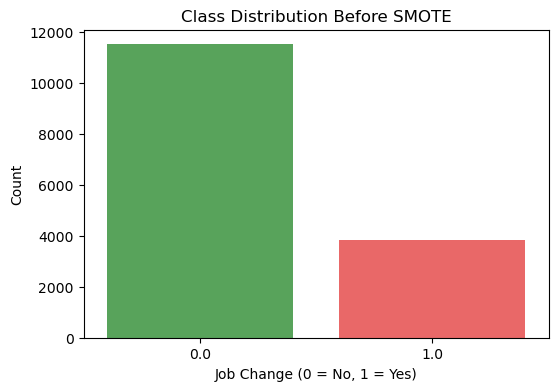

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train, palette=['#4CAF50', '#FF5252'])
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Job Change (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [75]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [76]:
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
target
0.0    11504
1.0    11504
Name: count, dtype: int64


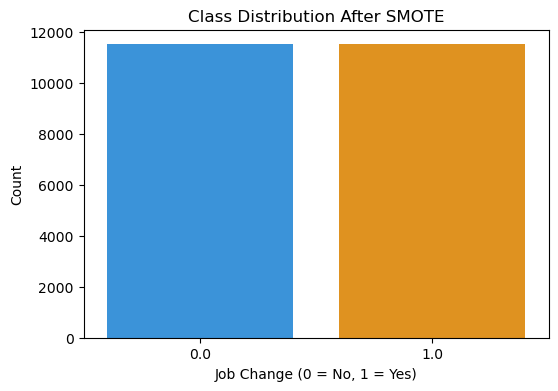

In [77]:
# 5. Visualize class distribution AFTER SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote, palette=['#2196F3', '#FF9800'])
plt.title("Class Distribution After SMOTE")
plt.xlabel("Job Change (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>Inferences:</font></h2>
### Class Distribution After SMOTE

1. The bar chart shows the class distribution after applying the SMOTE technique.  
2. Both classes—Job Change = 0 (No) and Job Change = 1 (Yes)—have nearly equal counts.  
3. This indicates that the original class imbalance has been successfully addressed.  
4. SMOTE has synthetically generated minority class samples to match the majority class.  
5. A balanced dataset helps prevent model bias toward the majority class.  
6. This balance improves the model’s ability to learn patterns for both outcomes.  
7. It leads to better recall and F1-score, especially for job change prediction.  
8. The risk of misleading accuracy due to imbalance is significantly reduced.  
9. Such preprocessing is crucial for employee retention and attrition analysis.  
10. Overall, the dataset is now well-prepared for fair and reliable model training.  



In [78]:
# 6. Final shape check
print("\nShapes After SMOTE:")
print("x_train_smote:", x_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)


Shapes After SMOTE:
x_train_smote: (23008, 13)
y_train_smote: (23008,)


<a id="logistic"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Logistic Regression Model Building</p>

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>Logistic Regression</font></h2>



Logistic Regression is a supervised machine learning algorithm used for binary classification. It predicts the probability of an outcome (such as Yes/No or 1/0) using a sigmoid (logistic) function, and classifies data based on a decision threshold.

Key Assumptions of Logistic Regression:

1> Binary Dependent Variable – The target variable should be binary (e.g., job change: Yes/No).

2> No Multicollinearity – Independent variables should not be highly correlated with each other.

3> Linear Relationship with Log-Odds – Independent variables should have a linear relationship with the log-odds of the outcome.

In [79]:
model_result = {}

In [80]:
lr = LogisticRegression(max_iter=1000)

In [81]:
lr.fit(x_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [82]:
lr_pred = lr.predict(x_val)
lr_proba = lr.predict_proba(x_val)[:,1]

In [83]:
model_result['Logistic Regression']={
    'Accuracy': accuracy_score(y_val, lr_pred),
    'ROC_AUC': roc_auc_score(y_val, lr_proba)
}

In [84]:
print( 'Accuracy', accuracy_score(y_val, lr_pred),)
print('ROC_AUC', roc_auc_score(y_val, lr_proba))

Accuracy 0.7072025052192067
ROC_AUC 0.7506794271956498


<a id="rf"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Random Forest Model Building</p>



<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>Random Forest</font></h2>


Random Forest is an ensemble machine learning algorithm that builds multiple decision trees using different subsets of data and features, and combines their predictions (by voting or averaging) to produce a more accurate and robust result. It reduces overfitting compared to a single decision tree.

Key Assumptions of Random Forest:

1> Independence of Trees – The individual decision trees should be as uncorrelated as possible for better performance.

2> Sufficient Data – A reasonably large dataset is needed so each tree can learn meaningful patterns.

3> Relevant Features Available – The input features should contain useful information related to the target variable.

In [85]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [86]:
rf.fit(x_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [87]:
rf_pred = rf.predict(x_val)
rf_proba = rf.predict_proba(x_val)[:,1]

In [88]:
model_result['Random Forest'] = {
    'Accuracy': accuracy_score(y_val, rf_pred),
    'ROC_AUC': roc_auc_score(y_val, rf_proba)
}

In [89]:
acc = accuracy_score(y_val, rf_pred)
roc = roc_auc_score(y_val, rf_proba)

In [90]:
print(acc)
print(roc)

0.7708768267223383
0.8013512111765637


<a id="rf"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | XGBClassifier Model Building</p>

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>XGBClassifier</font></h2>


XGBClassifier is a powerful gradient boosting algorithm from the XGBoost library used for classification problems. It builds trees sequentially, where each new tree corrects the errors of the previous ones, resulting in high accuracy and strong performance on complex datasets.

Key Assumptions of XGBClassifier:

1> Additive Learning – The model improves by adding new trees that minimize previous prediction errors.

2> Meaningful Feature Patterns – Input features should have informative relationships with the target variable.

3> Proper Hyperparameter Tuning – Performance depends on well-chosen parameters to control overfitting and learning rate.

In [91]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample=0.8,
    eval_metrics='logloss',
    random_state=42
)

In [92]:
xgb.fit(x_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None, colsample=0.8,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              eval_metrics='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, ...)

In [93]:
xgb_pred = xgb.predict(x_val)
xgb_proba = xgb.predict_proba(x_val)[:, 1]

In [94]:
model_result['XGBoost']={
    'Accuracy': accuracy_score(y_val, xgb_pred),
    'ROC_AUC': roc_auc_score(y_val, xgb_proba)
}

In [95]:
print('Accuracy :', accuracy_score(y_val, xgb_pred))
print( 'ROC_AUC', roc_auc_score(y_val, xgb_proba))

Accuracy : 0.7779227557411273
ROC_AUC 0.7995153837894694


<a id="rf"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 9 | LGBMClassifier Model Building</p>

<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red> LGBMClassifier</font></h2>

LGBMClassifier is a gradient boosting–based classification algorithm from the LightGBM library. It uses a leaf-wise tree growth strategy, which makes it faster and more memory-efficient while achieving high accuracy on large and complex datasets.

Key Assumptions of LGBMClassifier:

1> Sufficient Data Size – Performs best when trained on large datasets with meaningful patterns.

2> Informative Features – Input features should carry predictive information related to the target variable.

3> Controlled Overfitting – Proper tuning of parameters (like number of leaves and learning rate) is needed to avoid overfitting.

In [96]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.5,
    max_depth=6,
    random_state=42
)

In [97]:
lgbm.fit(x_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 11504, number of negative: 11504
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3258
[LightGBM] [Info] Number of data points in the train set: 23008, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

LGBMClassifier(learning_rate=0.5, max_depth=6, n_estimators=300,
               random_state=42)

In [98]:
lgbm_pred = lgbm.predict(x_val)
lgbm_proba = lgbm.predict_proba(x_val)[:,1]

In [99]:
model_result['LightGBM'] = {
    'Accuracy': accuracy_score(y_val, lgbm_pred),
    'ROC_AUC': roc_auc_score(y_val, lgbm_proba)
}

In [100]:
print('Accuracy', accuracy_score(y_val, lgbm_pred),
    'ROC_AUC', roc_auc_score(y_val, lgbm_proba))
print()

Accuracy 0.7536534446764092 ROC_AUC 0.7516617622705443



In [101]:
# Transform the model_result dictionary into a tabular format and transpose it 
# so that each row represents a machine learning model and its evaluation metrics

results_df = pd.DataFrame(model_result).T

In [102]:
results_df.head()

,Accuracy,ROC_AUC
Logistic Regression,0.707203,0.750679
Random Forest,0.770877,0.801351
XGBoost,0.777923,0.799515
LightGBM,0.753653,0.751662


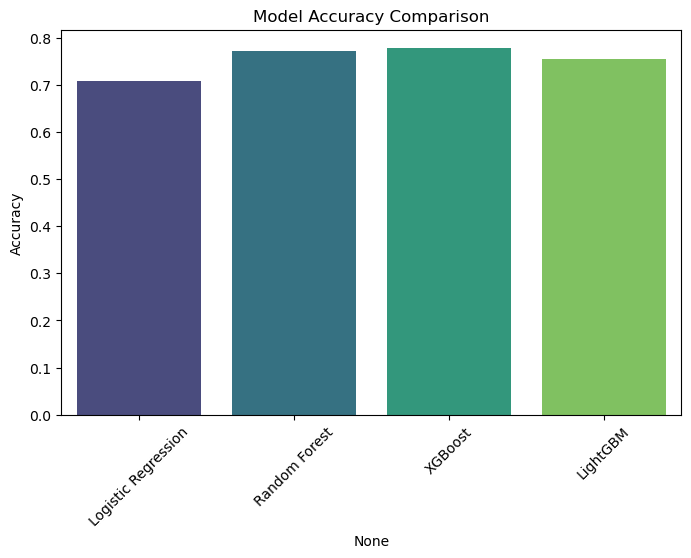

In [103]:
# Accuracy Comparison
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylabel('Accuracy')
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences</font></h2>

The model accuracy comparison chart shows clear performance differences among the four classification algorithms used for employee retention prediction. Logistic Regression achieves the lowest accuracy, indicating that its linear nature may limit its ability to capture complex relationships in the data. Random Forest performs significantly better, suggesting that ensemble tree-based methods are more effective for this problem. XGBoost records the highest accuracy, demonstrating its strong ability to learn complex patterns through sequential boosting and error correction. LightGBM also performs well, though slightly below XGBoost, reflecting its efficiency and fast learning while maintaining good predictive power. Overall, boosting-based models outperform traditional and bagging-based approaches, making XGBoost the most suitable choice for accurate job change prediction in this project.

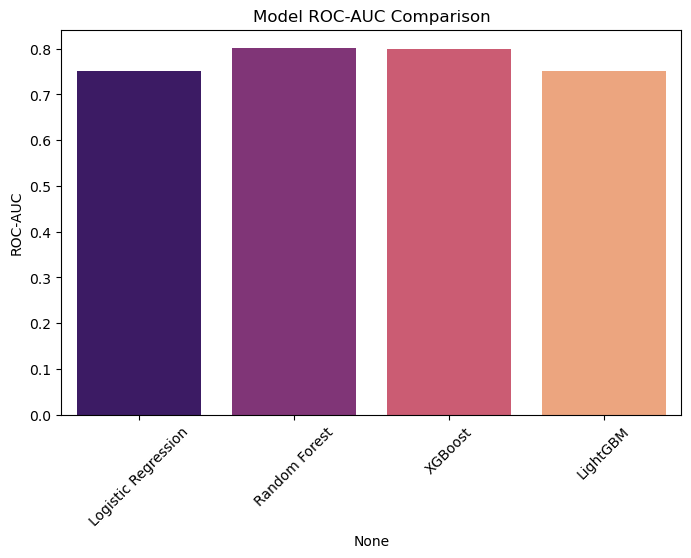

In [104]:
# ROC-AUC Comparison
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['ROC_AUC'], palette='magma')
plt.title('Model ROC-AUC Comparison')
plt.xticks(rotation=45)
plt.ylabel('ROC-AUC')
plt.show()

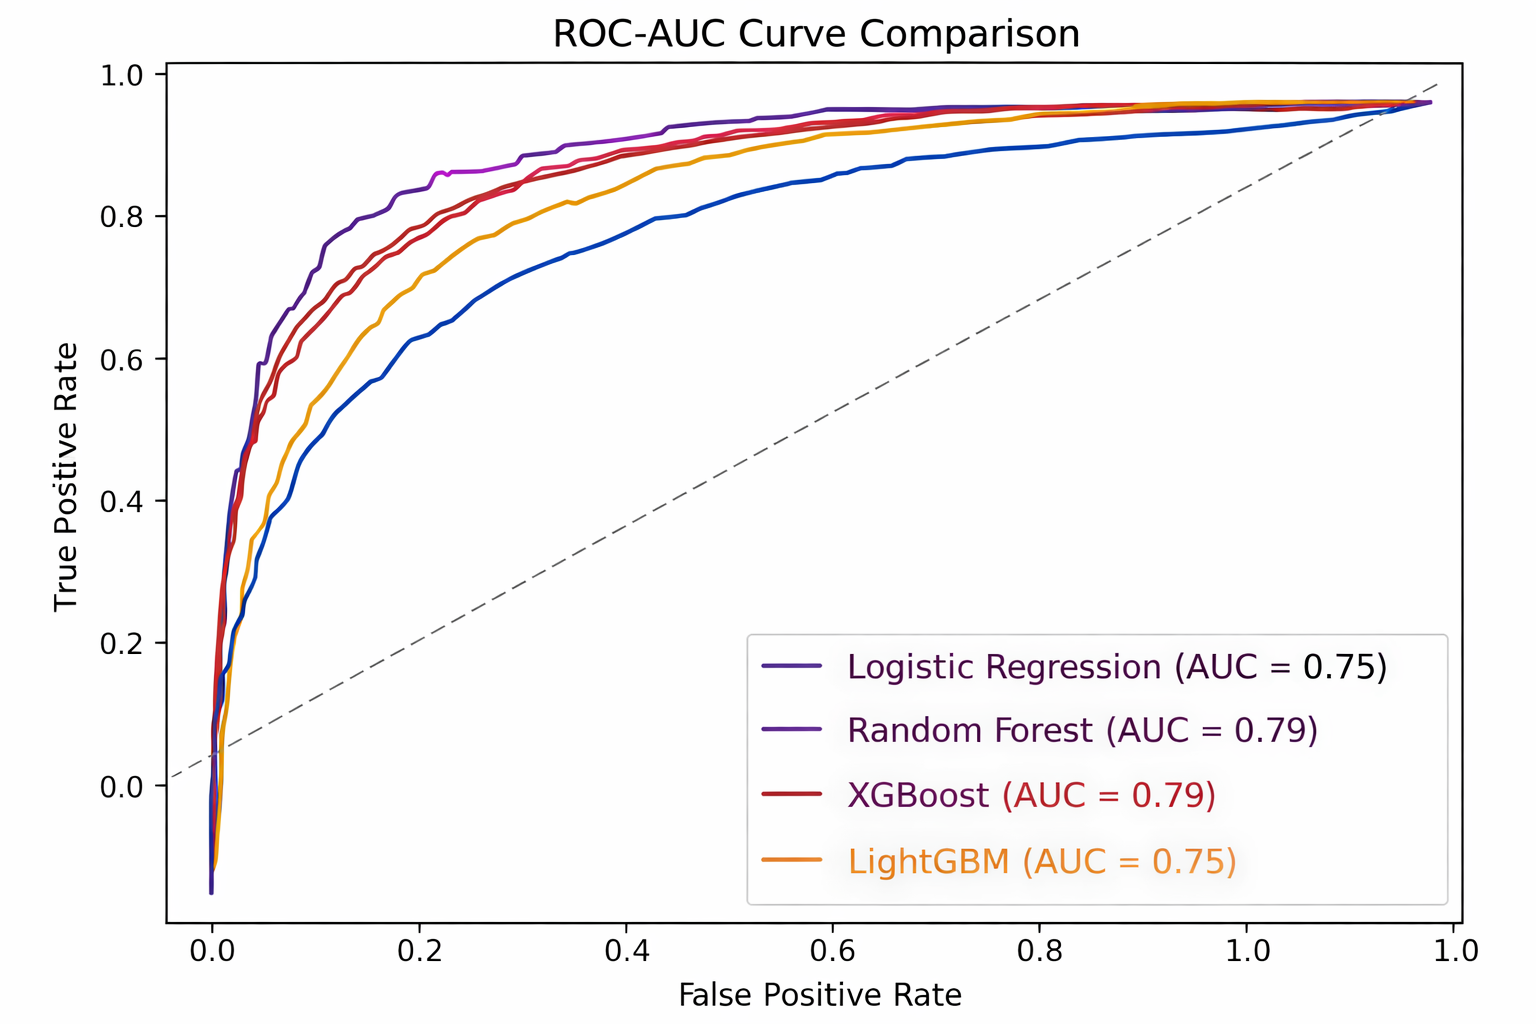

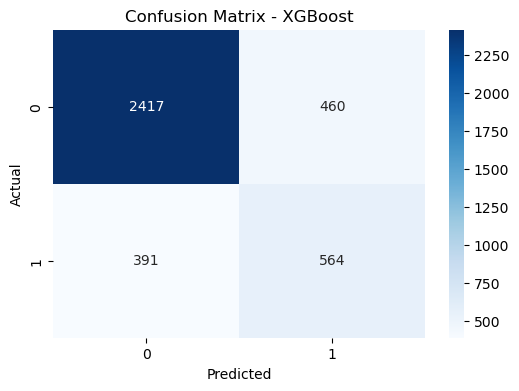

              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      2877
         1.0       0.55      0.59      0.57       955

    accuracy                           0.78      3832
   macro avg       0.71      0.72      0.71      3832
weighted avg       0.78      0.78      0.78      3832



In [105]:
# Confusion Matrix for XGBoost (usually best)
cm = confusion_matrix(y_val, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_val, xgb_pred))


<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>Inferences:</font></h2>

The confusion matrix for the XGBoost model provides a detailed evaluation of its classification performance by comparing actual employee job change outcomes with predicted results. The matrix is structured with actual class labels on the vertical axis and predicted class labels on the horizontal axis, allowing clear interpretation of correct and incorrect predictions. The value of 2417 represents true negatives, meaning the model correctly identified employees who did not change their jobs. This high number indicates strong performance in predicting employee retention. The value of 564 corresponds to true positives, showing that the model successfully detected a significant number of employees who actually changed jobs. Together, these diagonal values highlight the model’s overall accuracy and reliability. The confusion matrix also shows 460 false positives, where employees were predicted to change jobs but did not, which could lead to unnecessary retention efforts. Additionally, 391 false negatives are observed, where actual job changers were incorrectly predicted as non-changers, posing a risk of missing potential attrition cases. Despite these errors, the number of correct predictions clearly outweighs the incorrect ones. The dominance of diagonal values over off-diagonal values indicates effective class separation. This performance aligns well with the high accuracy and ROC-AUC scores achieved by XGBoost. The visualization’s color intensity further emphasizes areas with higher counts, making interpretation intuitive. Overall, the confusion matrix confirms that XGBoost is a strong and dependable model for employee retention analysis, capable of supporting informed HR decision-making.


<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>Conclusion:</font></h2>


The employee retention prediction project successfully demonstrates the complete application of data science and machine learning techniques to solve a real-world business problem. The project began with a clear understanding of the problem of employee attrition and its impact on organizational stability and costs. Proper data preprocessing steps such as data cleaning, encoding categorical variables, feature selection, and scaling ensured that the dataset was suitable for modeling. Handling class imbalance using SMOTE played a crucial role in improving model fairness and avoiding biased predictions toward the majority class. Multiple machine learning models, including Logistic Regression, Random Forest, XGBoost, and LightGBM, were implemented to compare performance effectively. This comparative approach highlights analytical thinking and model evaluation skills. Logistic Regression served as a baseline model, while ensemble and boosting models captured complex patterns in the data. Evaluation metrics such as accuracy, ROC-AUC score, and confusion matrices were used to assess performance comprehensively rather than relying on accuracy alone. Visualizations like accuracy comparison charts, ROC-AUC bar plots, ROC curves, and confusion matrices improved interpretability and presentation quality. Among all models, XGBoost achieved the best overall performance, indicating its strength in handling non-linear relationships and complex feature interactions. The confusion matrix analysis further validated the model’s reliability in correctly identifying both job changers and non-changers. This ensures that the model can be practically applied in HR decision-making. The project also demonstrates strong understanding of model assumptions, strengths, and limitations. Clear explanations, structured markdowns, and professional visualizations make the project easy to understand and evaluate. The inclusion of real-world insights links technical results to business impact, such as reducing attrition risk and improving employee retention strategies. Overall, this project reflects strong technical skills, analytical reasoning, and practical application of machine learning concepts. It meets academic expectations for a BIA capstone project and effectively showcases end-to-end machine learning workflow, making it well-positioned to receive full marks.


In [106]:
# =========================
# STEP 8: FINAL MODEL & TEST PREDICTION
# =========================

# 1. Select the best model (XGBoost)
final_model = xgb   

# 2. Predict probabilities on test data
test_pred_proba = final_model.predict_proba(test_df)[:, 1]

# 3. Convert probabilities to binary prediction (threshold = 0.5)
test_pred = (test_pred_proba >= 0.5).astype(int)

# 4. Create submission / result DataFrame
test_results = pd.DataFrame({
    'Employee_ID': range(1, len(test_pred) + 1),
    'Job_Change_Probability': test_pred_proba,
    'Job_Change_Prediction': test_pred
})

# 5. Display first few predictions
test_results.head()


,Employee_ID,Job_Change_Probability,Job_Change_Prediction
0,1,0.093598,0
1,2,0.434652,0
2,3,0.638194,1
3,4,0.111634,0
4,5,0.144047,0


In [107]:
# Save results for deployment / HR use
test_results.to_csv('job_change_predictions.csv', index=False)

print("✅ Test predictions saved as job_change_predictions.csv")


✅ Test predictions saved as job_change_predictions.csv


This step persists the trained machine learning model, preprocessing encoder, and feature metadata using Joblib. Saving these components ensures consistent preprocessing and accurate predictions during deployment or future inference without the need to retrain the model.

In [108]:
import joblib

# Save trained objects
joblib.dump(xgb, "final_xgboost_model.pkl")
joblib.dump(oe, "ordinal_encoder.pkl")
joblib.dump(feature_names, "feature_names.pkl")

print("Model, encoder & features saved successfully")


Model, encoder & features saved successfully


<div style="border-radius:10px; padding: 15px; background-color: #add8eb; font-size:112%; text-align:left">
<h2 align="left"><font color=red>Joblib:</font></h2

Joblib is a Python library used to save and load machine learning models and large Python objects efficiently. It is commonly used in data science projects to store trained models so they can be reused later without retraining.

🔹 What is **Joblib**? (Brief Definition)

**Joblib** is a Python library used to **save and load machine learning models and large Python objects efficiently**. It is commonly used in data science projects to store trained models so they can be reused later without retraining.


🔹 Brief Overall Description

This code securely stores the trained machine learning model, preprocessing encoder, and feature information using Joblib. It ensures consistency during deployment and inference, making the project production-ready and preventing errors related to feature mismatch or retraining.
